# Ray tracing simulation # 

In [ ]:
import os, importlib
import mitsuba as mi
print(mi.variants())

# mi.set_variant("llvm_ad_rgb")
mi.set_variant("llvm_ad_mono_polarized")

# Import relevant components from Sionna RT
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera,\
                      PathSolver, RadioMapSolver, subcarrier_frequencies

import sionna

# Other imports
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np


['scalar_rgb', 'scalar_spectral', 'scalar_spectral_polarized', 'llvm_ad_rgb', 'llvm_ad_mono', 'llvm_ad_mono_polarized', 'llvm_ad_spectral', 'llvm_ad_spectral_polarized', 'cuda_ad_rgb', 'cuda_ad_mono', 'cuda_ad_mono_polarized', 'cuda_ad_spectral', 'cuda_ad_spectral_polarized']


In [2]:
# Import scene as xml file
scene = load_scene("WindowsConfig/WindowsConfig.xml")

scene.tx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern='iso',
                             polarization='V')

scene.rx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern='iso',
                             polarization='V')

tx = Transmitter("tx", [0, 4, 1.5])
scene.add(tx)

# Rx positions
x1, y1 = -10, 12.5
x2, y2 = 10, 12.5
x3, y3 = 10, -12.5
x4, y4 = -10, -12.5

rx1 = Receiver("rx", [x1, y1, 1.5])
rx2 = Receiver("rx2", [x2, y2, 1.5])
rx3 = Receiver("rx3", [x3, y3, 1.5])
rx4 = Receiver("rx4", [x4, y4, 1.5])
scene.add(rx1)
scene.add(rx2)
scene.add(rx3)
scene.add(rx4)

scene.preview()

In [3]:
# mi.set_variant("llvm_ad_mono_polarized")
rm_solver = RadioMapSolver()

rm = rm_solver(scene=scene,
               max_depth=7,
               cell_size=[0.1,0.1],
               samples_per_tx=10**8)

In [4]:
scene.preview(radio_map=rm)

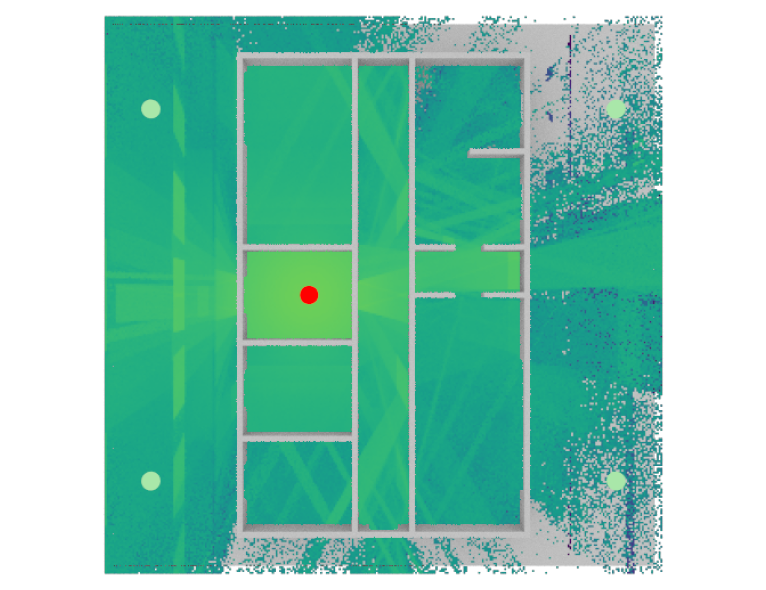

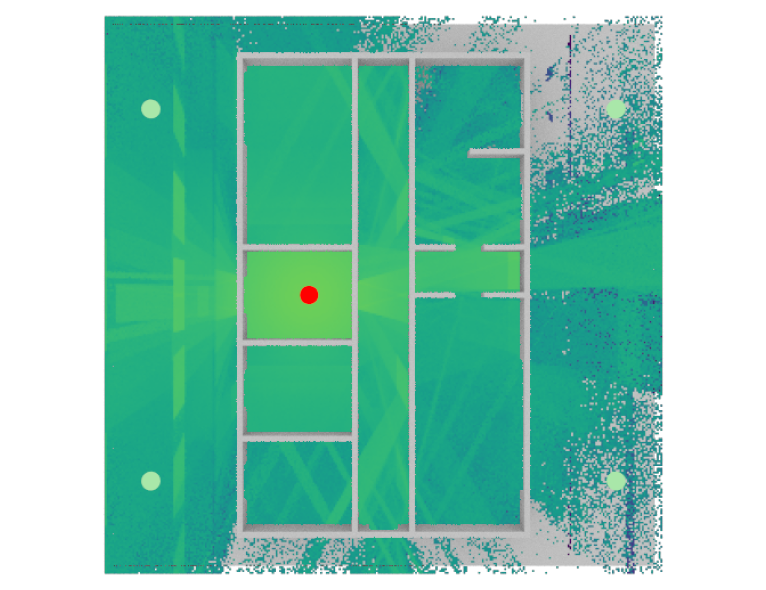

In [5]:
camera = Camera(position=[0,0,50],
                look_at=[0,0,0])

scene.render(camera=camera,radio_map=rm)


In [ ]:
rm = rm_solver(scene=scene,
               max_depth=7,
               cell_size=[0.1,0.1],
               samples_per_tx=10**7)

In [7]:
rm.show(metric="path_gain")

KeyboardInterrupt: 

<Figure size 640x480 with 0 Axes>

In [41]:
pathSolver = PathSolver()
paths = pathSolver(scene=scene, max_depth=7)

In [40]:
# 1. Get current valid mask to know the correct shape
# This is crucial: 'valid' might have fewer dimensions than 'a'
original_valid_np = paths.valid.numpy()
target_shape = original_valid_np.shape

# 2. Get signal magnitude from 'a'
a_r, a_i = paths.a
a_r_np, a_i_np = a_r.numpy(), a_i.numpy()
magnitudes = np.sqrt(a_r_np**2 + a_i_np**2)

# 3. Reduce magnitude to match 'valid' shape
# If 'a' has extra antenna dimensions (dims 1 and 3), max over them
# Example: Convert [Rx, RxAnt, Tx, TxAnt, Paths] -> [Rx, Tx, Paths]
if len(magnitudes.shape) > len(target_shape):
    # Reduce dimensions 1 and 3 (antenna arrays) by taking the max power across antennas
    # Adjust axes based on your actual shape. Typically:
    # Axis 0=Rx, 1=RxAnt, 2=Tx, 3=TxAnt, 4=Paths
    reduced_magnitudes = np.max(magnitudes, axis=(1, 3)) 
else:
    reduced_magnitudes = magnitudes

# 4. Create the filter mask
# Keep paths where power is > 5% of peak
keep_mask = np.zeros(target_shape, dtype=bool)

# Iterate over Rx/Tx pairs to calculate local thresholds
for i in range(target_shape[0]): # Rx
    for j in range(target_shape[1]): # Tx
        # Get all paths for this link
        path_powers = reduced_magnitudes[i, j, :]
        max_val = np.max(path_powers)
        
        if max_val > 0:
            # Create boolean filter
            keep_mask[i, j, :] = path_powers >= (0.2 * max_val)

# 5. Combine with original validity (Logical AND)
# This ensures we don't accidentally "revive" non-existent paths
final_mask = keep_mask & original_valid_np

# 6. Apply to the internal _valid variable
# Use TensorXb (Extended Boolean Tensor)
paths._valid = mi.TensorXb(final_mask)

# 7. (Optional) Zero out 'a' for consistency
# You might need to broadcast the mask back to 'a's shape if they differ
paths._a = (
    mi.TensorXf(a_r_np * final_mask[:, None, :, None, :]), # Broadcast if needed
    mi.TensorXf(a_i_np * final_mask[:, None, :, None, :])
)

# 8. Preview
scene.preview(paths=paths)

In [42]:
scene.preview(paths=paths)

[[[5.77018e-08, 6.12651e-08, 6.99157e-08, .. 57 skipped .., 5.77442e-08, 7.06503e-08, 6.74039e-08]],
 [[5.90456e-08, 6.99157e-08, 6.07178e-08, .. 57 skipped .., 5.52389e-08, 8.71324e-08, 7.06503e-08]],
 [[6.84619e-08, 6.43571e-08, 8.74447e-08, .. 57 skipped .., -1, -1, -1]],
 [[8.55389e-08, 6.8462e-08, 8.64858e-08, .. 57 skipped .., -1, -1, -1]]]
(4, 1, 1, 1, 63)
(4, 1, 63)


<Figure size 2000x2000 with 0 Axes>

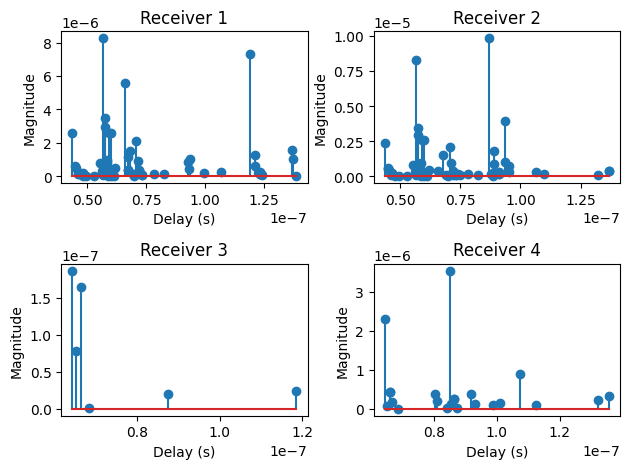

In [54]:
# Channel impulse response of the path
cir = paths.cir(sampling_frequency=2.4e9,
                num_time_steps=1,
                normalize_delays=False)


coeffs_re, coeffs_im = cir[0]
delays = cir[1]

print(delays)

coeffs_re = coeffs_re[..., 0]
coeffs_im = coeffs_im[..., 0]
delays = delays[..., :].numpy()
print(coeffs_re.shape)
print(delays.shape)

magnitudes = np.abs(coeffs_re.numpy() + 1j*coeffs_im.numpy())
magnitudes = magnitudes.reshape(magnitudes.shape[0], -1)
delays = delays.reshape(delays.shape[0], -1)

# Removing points corresponding to -1 delay (no path)
mag_ = magnitudes
del_ = delays
magnitudes = []
delays = []
for i in range(mag_.shape[0]):
    mask = del_[i] >= 0
    delays.append(del_[i][mask])
    magnitudes.append(mag_[i][mask])



plt.figure(figsize=(20,20))
plt.subplots(2,2)

plt.subplot(2,2,1)
plt.stem(delays[0], magnitudes[0])
plt.title("Receiver 1")
plt.xlabel("Delay (s)")
plt.ylabel("Magnitude")

plt.subplot(2,2,2)
plt.stem(delays[1], magnitudes[1])
plt.title("Receiver 2")
plt.xlabel("Delay (s)")
plt.ylabel("Magnitude")

plt.subplot(2,2,3)
plt.stem(delays[2], magnitudes[2])
plt.title("Receiver 3")
plt.xlabel("Delay (s)")
plt.ylabel("Magnitude")

plt.subplot(2,2,4)
plt.stem(delays[3], magnitudes[3])
plt.title("Receiver 4")
plt.xlabel("Delay (s)")
plt.ylabel("Magnitude")

plt.tight_layout()
plt.show()

(4, 12)


<Figure size 2000x2000 with 0 Axes>

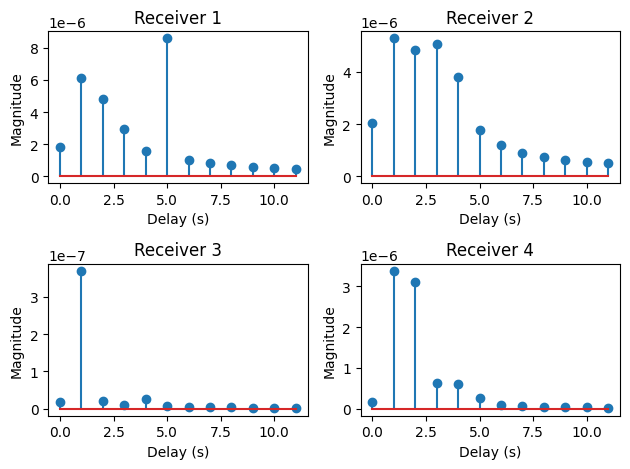

In [58]:
# Channel impulse response of the path
taps = paths.taps(bandwidth=50e6, l_min=-1, l_max=10)

taps_re, taps_im = taps[0], taps[1]
taps_mag = np.sqrt(taps_re.numpy()**2 + taps_im.numpy()**2)
taps_mag = taps_mag.reshape(taps_mag.shape[0], -1)
print(taps_mag.shape)


plt.figure(figsize=(20,20))
plt.subplots(2,2)

plt.subplot(2,2,1)
plt.stem(taps_mag[0])
plt.title("Receiver 1")
plt.xlabel("Delay (s)")
plt.ylabel("Magnitude")

plt.subplot(2,2,2)
plt.stem(taps_mag[1])
plt.title("Receiver 2")
plt.xlabel("Delay (s)")
plt.ylabel("Magnitude")

plt.subplot(2,2,3)
plt.stem(taps_mag[2])
plt.title("Receiver 3")
plt.xlabel("Delay (s)")
plt.ylabel("Magnitude")

plt.subplot(2,2,4)
plt.stem(taps_mag[3])
plt.title("Receiver 4")
plt.xlabel("Delay (s)")
plt.ylabel("Magnitude")

plt.tight_layout()
plt.show()

(4, 22)


<Figure size 2000x2000 with 0 Axes>

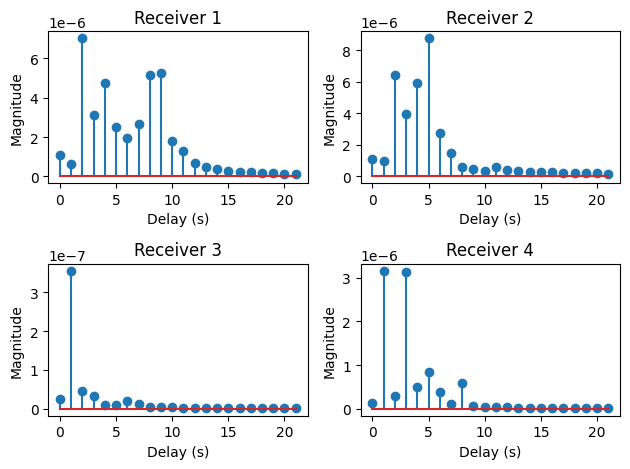

In [59]:
# Channel impulse response of the path
taps = paths.taps(bandwidth=100e6, l_min=-1, l_max=20)

taps_re, taps_im = taps[0], taps[1]
taps_mag = np.sqrt(taps_re.numpy()**2 + taps_im.numpy()**2)
taps_mag = taps_mag.reshape(taps_mag.shape[0], -1)
print(taps_mag.shape)


plt.figure(figsize=(20,20))
plt.subplots(2,2)

plt.subplot(2,2,1)
plt.stem(taps_mag[0])
plt.title("Receiver 1")
plt.xlabel("Delay (s)")
plt.ylabel("Magnitude")

plt.subplot(2,2,2)
plt.stem(taps_mag[1])
plt.title("Receiver 2")
plt.xlabel("Delay (s)")
plt.ylabel("Magnitude")

plt.subplot(2,2,3)
plt.stem(taps_mag[2])
plt.title("Receiver 3")
plt.xlabel("Delay (s)")
plt.ylabel("Magnitude")

plt.subplot(2,2,4)
plt.stem(taps_mag[3])
plt.title("Receiver 4")
plt.xlabel("Delay (s)")
plt.ylabel("Magnitude")

plt.tight_layout()
plt.show()

In [ ]:
# Filtering out small magnitudes

relative_threshold = 0.05  # 5% of the maximum magnitude
for i in range(4):
    max_magnitude = np.max(magnitudes[i])
    threshold = relative_threshold * max_magnitude
    mask = magnitudes[i] >= threshold
    delays[i] = delays[i][mask]
    magnitudes[i] = magnitudes[i][mask]

<Figure size 2000x2000 with 0 Axes>

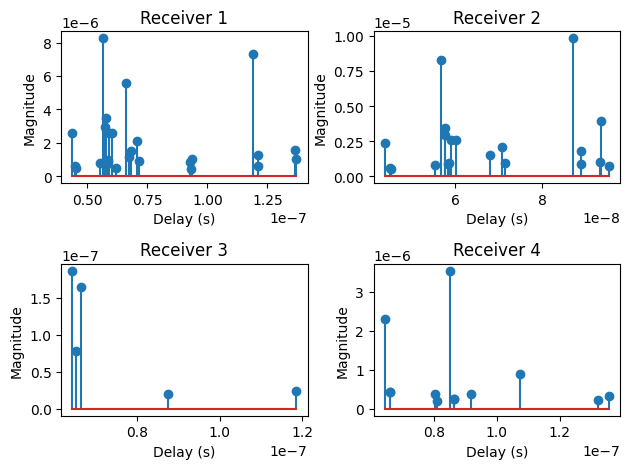

In [10]:
plt.figure(figsize=(20,20))
plt.subplots(2,2)

plt.subplot(2,2,1)
plt.stem(delays[0], magnitudes[0])
# plt.stem(delays[0][np.argmax(magnitudes[0])], np.max(magnitudes[0]), linefmt='r-', markerfmt='ro', basefmt='r-')
plt.title("Receiver 1")
plt.xlabel("Delay (s)")
plt.ylabel("Magnitude")

plt.subplot(2,2,2)
plt.stem(delays[1], magnitudes[1])
# plt.stem(delays[1][np.argmax(magnitudes[1])], np.max(magnitudes[1]), linefmt='r-', markerfmt='ro', basefmt='r-')
plt.title("Receiver 2")
plt.xlabel("Delay (s)")
plt.ylabel("Magnitude")

plt.subplot(2,2,3)
plt.stem(delays[2], magnitudes[2])
# plt.stem(delays[2][np.argmax(magnitudes[2])], np.max(magnitudes[2]), linefmt='r-', markerfmt='ro', basefmt='r-')
plt.title("Receiver 3")
plt.xlabel("Delay (s)")
plt.ylabel("Magnitude")

plt.subplot(2,2,4)
plt.stem(delays[3], magnitudes[3])
# plt.stem(delays[3][np.argmax(magnitudes[3])], np.max(magnitudes[3]), linefmt='r-', markerfmt='ro', basefmt='r-')
plt.title("Receiver 4")
plt.xlabel("Delay (s)")
plt.ylabel("Magnitude")

plt.tight_layout()
plt.show()

## Least squares algorithm ##

In [11]:
# Build matrix A
A = np.array([[2*(x1 - x2), 2*(y1 - y2)],
              [2*(x1 - x3), 2*(y1 - y3)],
              [2*(x1 -  x4), 2*(y1 - y4)]])

# Build vector b for the strongest path
c = 3e8  # Speed of light
t1 = delays[0][np.argmax(magnitudes[0])]
t2 = delays[1][np.argmax(magnitudes[1])]
t3 = delays[2][np.argmax(magnitudes[2])]
t4 = delays[3][np.argmax(magnitudes[3])]
print(t1, t2, t3, t4)

b = np.zeros((3,1))
b[0] = c**2*t2**2 - c**2*t1**2 + x1**2 - x2**2 + y1**2 - y2**2
b[1] = c**2*t3**2 - c**2*t1**2 + x1**2 - x3**2 + y1**2 - y3**2
b[2] = c**2*t4**2 - c**2*t1**2 + x1**2 - x4**2 + y1**2 - y4**2

print("Matrix A:")
print(A)
print("Vector b:")
print(b)

# Solve for (x, y) using least squares
X = np.linalg.inv(A.T @ A) @ A.T @ b

print(np.linalg.inv(A.T @ A))

print(f"Estimated position of the transmitter: x = {X[0][0]:.2f}, y = {X[1][0]:.2f}")
print("Actual position of the transmitter: x = 0, y = 4")
print("Error in position estimation: ", (np.sqrt((X[0][0]-0)**2 + (X[1][0]-4)**2)))

5.6641102e-08 8.7132406e-08 6.4357124e-08 8.495151e-08
Matrix A:
[[-40.   0.]
 [-40.  50.]
 [  0.  50.]]
Vector b:
[[394.54575453]
 [ 84.02624366]
 [360.76899432]]
[[0.00041667 0.00016667]
 [0.00016667 0.00026667]]
Estimated position of the transmitter: x = -4.27, y = 2.74
Actual position of the transmitter: x = 0, y = 4
Error in position estimation:  4.451577594135305


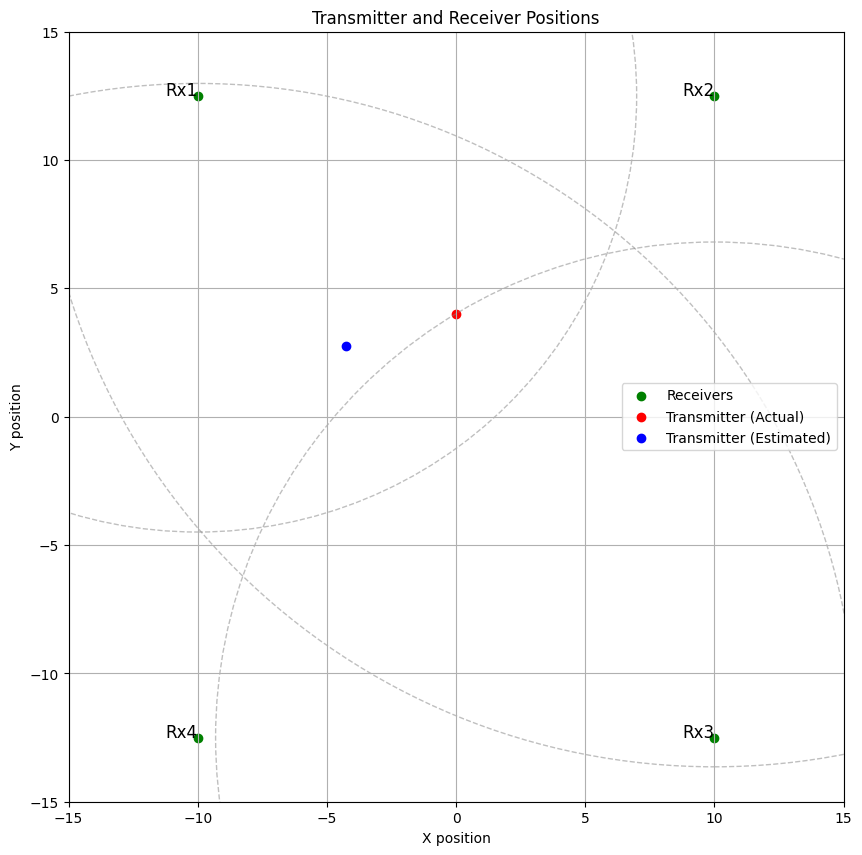

In [12]:
# Plot receivers and their circles of constant delay
plt.figure(figsize=(10,10))
plt.scatter([x1, x2, x3, x4], [y1, y2, y3, y4], c='green', label='Receivers')
plt.scatter([0], [4], c='red', label='Transmitter (Actual)')
plt.scatter([X[0][0]], [X[1][0]], c='blue', label='Transmitter (Estimated)')
for i, (x, y, delay) in enumerate(zip([x1, x2, x3, x4], [y1, y2, y3, y4],
                                     [t1, t2, t3, t4])):
    radius = 3e8 * delay
    circle = plt.Circle((x, y), radius, color='gray', fill=False, linestyle='--', alpha=0.5)
    plt.gca().add_artist(circle)
    plt.text(x, y, f'Rx{i+1}', fontsize=12, ha='right')
plt.legend()
plt.xlabel("X position")
plt.ylabel("Y position")
plt.xlim(-15, 15)
plt.ylim(-15, 15)
plt.title("Transmitter and Receiver Positions")
plt.grid(True)
plt.show()

In [13]:
# Build matrix A
A = np.array([[2*(x1 - x2), 2*(y1 - y2)],
              [2*(x1 - x3), 2*(y1 - y3)],
              [2*(x1 -  x4), 2*(y1 - y4)]])

# Build vector b for the first path
c = 3e8  # Speed of light
t1 = np.min(delays[0])
t2 = np.min(delays[1])
t3 = np.min(delays[2])
t4 = np.min(delays[3])
print(t1, t2, t3, t4)

b = np.zeros((3,1))
b[0] = (c*t2)**2 - (c*t1)**2 + x1**2 - x2**2 + y1**2 - y2**2
b[1] = (c*t3)**2 - (c*t1)**2 + x1**2 - x3**2 + y1**2 - y3**2
b[2] = (c*t4)**2 - (c*t1)**2 + x1**2 - x4**2 + y1**2 - y4**2

print("Matrix A:")
print(A)
print("Vector b:")
print(b)

# Solve for (x, y) using least squares
X = np.linalg.inv(A.T @ A) @ A.T @ b

print(np.linalg.inv(A.T @ A))

print(f"Estimated position of the transmitter: x = {X[0][0]:.2f}, y = {X[1][0]:.2f}")
print("Actual position of the transmitter: x = 0, y = 4")
print("Error in position estimation: ", (np.sqrt((X[0][0]-0)**2 + (X[1][0]-4)**2)))

4.37783e-08 4.37783e-08 6.4357124e-08 6.4357124e-08
Matrix A:
[[-40.   0.]
 [-40.  50.]
 [  0.  50.]]
Vector b:
[[  0.        ]
 [200.27698738]
 [200.27698738]]
[[0.00041667 0.00016667]
 [0.00016667 0.00026667]]
Estimated position of the transmitter: x = -0.00, y = 4.01
Actual position of the transmitter: x = 0, y = 4
Error in position estimation:  0.005539747666807315


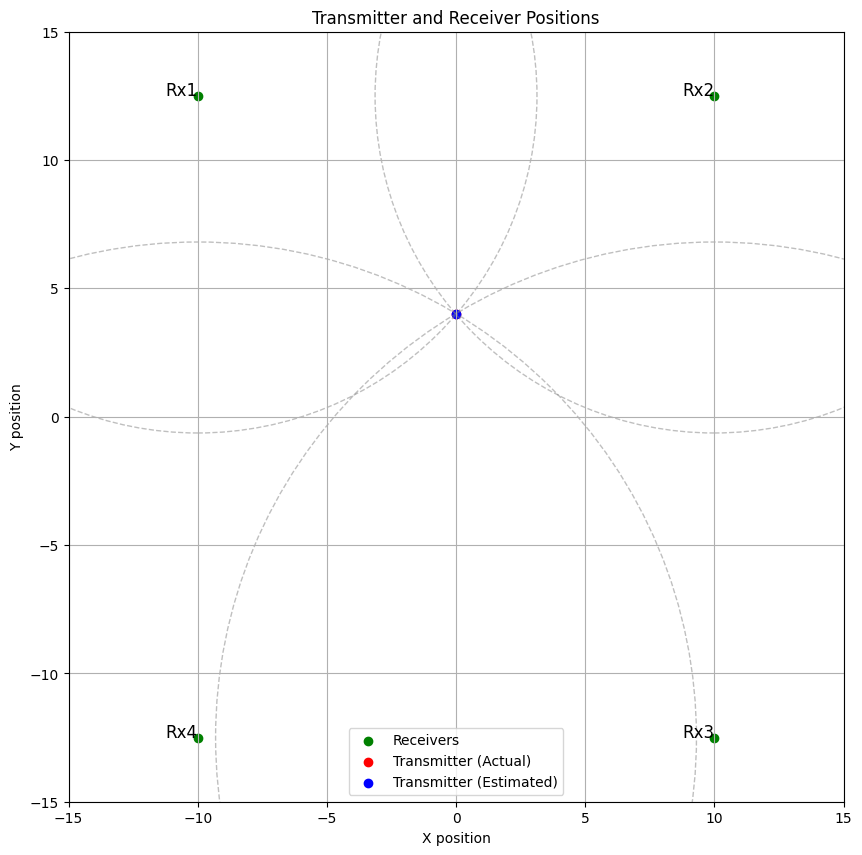

In [14]:
# Plot receivers and their circles of constant delay
plt.figure(figsize=(10,10))
plt.scatter([x1, x2, x3, x4], [y1, y2, y3, y4], c='green', label='Receivers')
plt.scatter([0], [4], c='red', label='Transmitter (Actual)')
plt.scatter([X[0][0]], [X[1][0]], c='blue', label='Transmitter (Estimated)')
for i, (x, y, delay) in enumerate(zip([x1, x2, x3, x4], [y1, y2, y3, y4],
                                     [t1, t2, t3, t4])):
    radius = 3e8 * delay
    circle = plt.Circle((x, y), radius, color='gray', fill=False, linestyle='--', alpha=0.5)
    plt.gca().add_artist(circle)
    plt.text(x, y, f'Rx{i+1}', fontsize=12, ha='right')
plt.legend()
plt.xlabel("X position")
plt.ylabel("Y position")
plt.xlim(-15, 15)
plt.ylim(-15, 15)
plt.title("Transmitter and Receiver Positions")
plt.grid(True)
plt.show()

In [15]:
# Tau rms calculation
def tau_rms(delays, magnitudes):
    """Compute the RMS delay spread given delays and magnitudes."""
    # Normalize magnitudes to get power
    power = magnitudes**2
    power /= np.sum(power)

    # Compute mean delay
    mean_delay = np.sum(delays * power) / np.sum(power)

    # Compute RMS delay spread
    rms_delay = np.sqrt(np.sum(((delays - mean_delay)**2) * power) / np.sum(power))

    return rms_delay

for i in range(4):
    rms_delay = tau_rms(delays[i], magnitudes[i])
    print(f"RMS Delay Spread for Receiver {i+1}: {rms_delay*1e9:.2f} ns")

RMS Delay Spread for Receiver 1: 27.80 ns
RMS Delay Spread for Receiver 2: 15.81 ns
RMS Delay Spread for Receiver 3: 5.36 ns
RMS Delay Spread for Receiver 4: 11.87 ns
